In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

Text(0.5, 0, '')

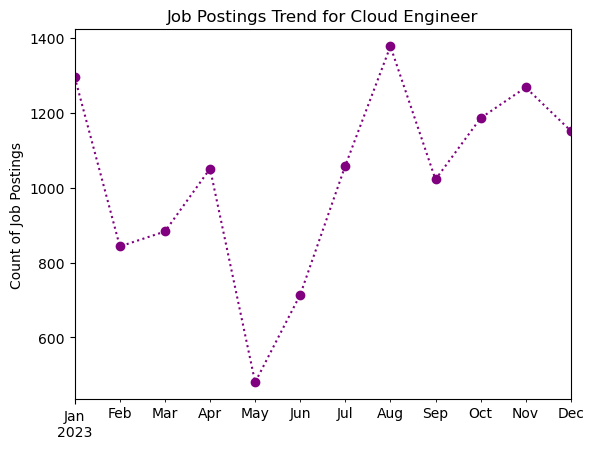

In [13]:
job_title = 'Cloud Engineer'

df_job = df[df['job_title_short'] == job_title].copy()
df_job['month'] = df_job['job_posted_date'].dt.to_period('M')
monthly_postings = df_job.groupby('month').size()

monthly_postings.plot(
    kind='line',
    linestyle=':',
    color='purple',
    marker='o')

plt.title(f'Job Postings Trend for {job_title}')
plt.ylabel('Count of Job Postings')
plt.xlabel('')


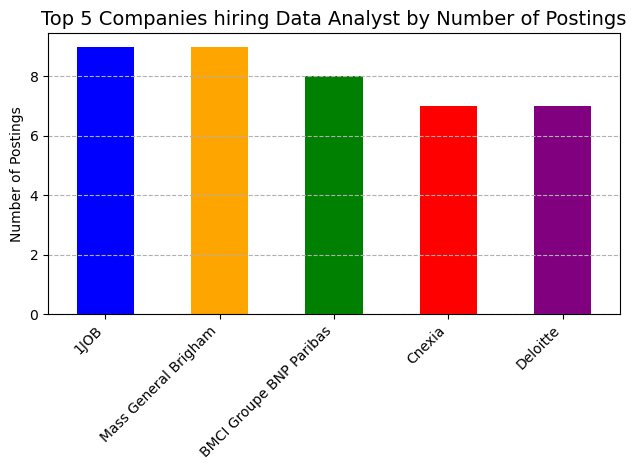

In [44]:
job_title = 'Data Analyst'
job_country = 'Morocco'

df_job = df[(df['job_title_short'] == job_title) & (df['job_country'] == job_country)].copy()
top_5_companies = df_job['company_name'].value_counts().head()  
top_5_companies = top_5_companies.reset_index(name='postings_count')

colors = ['blue', 'orange', 'green', 'red', 'purple']

top_5_companies.plot(kind='bar', x='company_name', y='postings_count', color=colors)

plt.ylabel('Number of Postings')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.title(f'Top 5 Companies hiring {job_title} by Number of Postings', fontsize=14)
plt.grid(axis='y', linestyle='--')
plt.legend().set_visible(False)
plt.tight_layout()